<a href="https://colab.research.google.com/github/alex-smith-uwec/CS491/blob/main/PreProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



In [ ]:
my_path="/content/drive/MyDrive/CS491NLP/Data/"

# Download a novel and prepare for analysis

Some pre-processing: download novel from Gutenberg, then remove preamble and postamble

In [ ]:
title = 'Metamorphosis'
tit='Meta' #short title for future reference if needed
author = 'Franz Kafka'
url = 'https://www.gutenberg.org/cache/epub/5200/pg5200.txt'
path = my_path

In [ ]:
import os
import urllib.request  # Import the module required for making HTTP requests



# Check if the file is stored locally
filename = my_path + title
if os.path.isfile(filename) and os.stat(filename).st_size != 0:
    print("{title} file already exists".format(title=title))
    with open(filename, 'r') as f:
        raw = f.read()
else:
    print("{title} file does not already exist. Grabbing from Project Gutenberg".format(title=title))
    response = urllib.request.urlopen(url)
    raw = response.read().decode('utf-8-sig')
    print("Saving {title} file".format(title=title))
    with open(filename, 'w') as outfile:
        outfile.write(raw)

Metamorphosis file already exists


In the file browser to the left, open the book. The text should (might?) appear in a cell on the right. Delete preamble and postamble, then save.

In [ ]:
##These two lines demonsrate that you have succeeded in removing the Guttenberg preamble and postamble

print(f"first 100 characters: {raw[:100]}")
print(f"last 100 characters: {raw[-100:]}")

first 100 characters: One morning, when Gregor Samsa woke from troubled dreams, he found himself transformed in his bed in
last 100 characters: ir destination Grete was the first to get up and stretch out her young body.                        


In [ ]:
# first, remove unwanted new line and tab characters from the text
for char in ["\n", "\r", "\d", "\t"]:
   raw = raw.replace(char, " ")

with open(filename, 'w') as outfile:
    outfile.write(raw)

In [ ]:
import nltk
from nltk import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
all_tokens=word_tokenize(raw)#.lower())

In [ ]:
len(all_tokens)

25135

In [ ]:
all_tokens[60:80]

['to',
 'cover',
 'it',
 'and',
 'seemed',
 'ready',
 'to',
 'slide',
 'off',
 'any',
 'moment',
 '.',
 'His',
 'many',
 'legs',
 ',',
 'pitifully',
 'thin',
 'compared',
 'with']

In [ ]:
clean_tokens=[word for word in all_tokens if word.isalpha()]

In [ ]:
clean_tokens[60:80]

['slide',
 'off',
 'any',
 'moment',
 'His',
 'many',
 'legs',
 'pitifully',
 'thin',
 'compared',
 'with',
 'the',
 'size',
 'of',
 'the',
 'rest',
 'of',
 'him',
 'waved',
 'about']

# Zipf's Law

[Zipf's Law Wiki](https://en.wikipedia.org/wiki/Zipf%27s_law)

In [ ]:
import numpy as np
from collections import Counter
from matplotlib import pyplot as plt

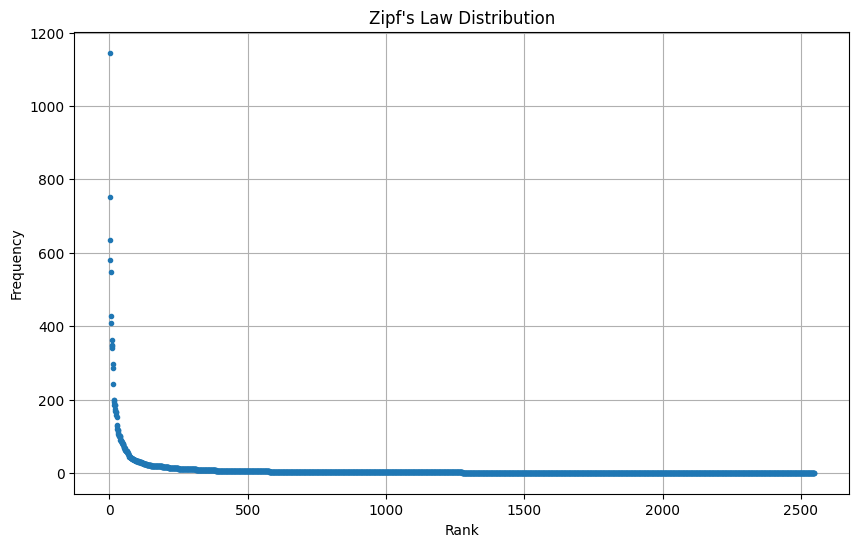

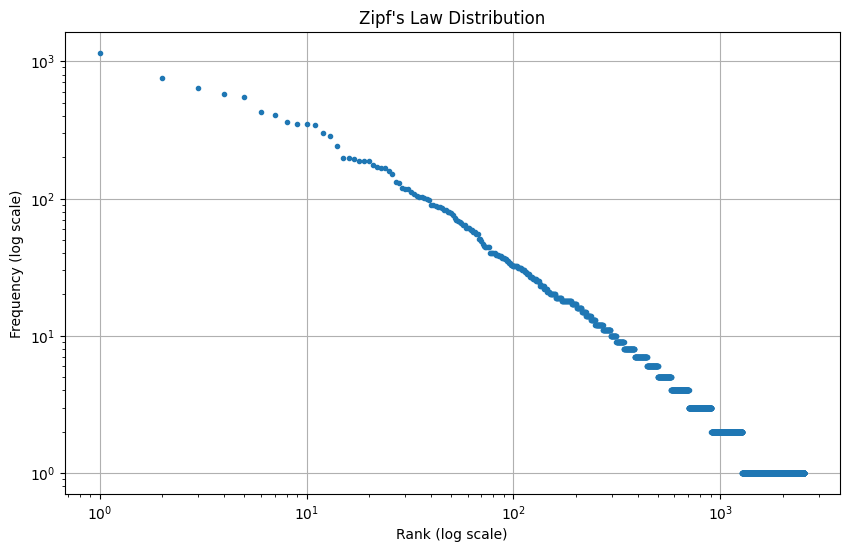

Estimated exponent 's' in Zipf's Law: 1.1590130184804603


In [ ]:
##Zipf's Law
clean_tokens_lower = [word.lower() for word in clean_tokens]
word_frequencies = Counter(clean_tokens_lower)
sorted_frequencies = sorted(word_frequencies.values(), reverse=True)

# Create an array of ranks (1, 2, 3, ...)
ranks = np.arange(1, len(sorted_frequencies) + 1)


plt.figure(figsize=(10, 6))
plt.plot(ranks, sorted_frequencies, marker='.', linestyle='None')
plt.title("Zipf's Law Distribution")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Plot the data on a log-log scale
plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_frequencies, marker='.', linestyle='None')
plt.title("Zipf's Law Distribution")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.grid(True)
plt.show()

from scipy.stats import linregress

# Assuming you have already calculated ranks and sorted_frequencies as mentioned earlier
log_ranks = np.log(ranks)
log_frequencies = np.log(sorted_frequencies)

# Fit a linear regression model to the log-log data
slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_frequencies)

# The slope of the regression line represents the estimated exponent 's'
estimated_s = -slope

print(f"Estimated exponent 's' in Zipf's Law: {estimated_s}")

# Stopwords, wordcloud, hapaxes, lexical dispersion

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words=stopwords.words('english')

In [ ]:
len(stop_words)

179

In [ ]:
#Note that All_words is case sensitive (later will use all_words)
#A reason for this is to preserve capitalization of proper names in a word cloud
All_words = [word for word in clean_tokens if word.casefold() not in stop_words]

In [ ]:
print(All_words[0:20])

['One', 'morning', 'Gregor', 'Samsa', 'woke', 'troubled', 'dreams', 'found', 'transformed', 'bed', 'horrible', 'vermin', 'lay', 'back', 'lifted', 'head', 'little', 'could', 'see', 'brown']


In [ ]:
All_fd=nltk.FreqDist(All_words)

In [ ]:
All_fd

FreqDist({'Gregor': 298, 'would': 183, 'room': 129, 'could': 118, 'sister': 101, 'father': 99, 'door': 86, 'mother': 84, 'back': 82, 'even': 78, ...})

In [ ]:
All_fd.most_common(100)

[('Gregor', 298),
 ('would', 183),
 ('room', 129),
 ('could', 118),
 ('sister', 101),
 ('father', 99),
 ('door', 86),
 ('mother', 84),
 ('back', 82),
 ('even', 78),
 ('way', 61),
 ('time', 59),
 ('said', 51),
 ('one', 50),
 ('little', 49),
 ('get', 44),
 ('still', 44),
 ('first', 42),
 ('made', 40),
 ('go', 40),
 ('see', 39),
 ('without', 39),
 ('head', 38),
 ('much', 38),
 ('chief', 37),
 ('clerk', 37),
 ('like', 36),
 ('open', 35),
 ('Samsa', 33),
 ('thought', 32),
 ('went', 32),
 ('family', 32),
 ('came', 31),
 ('left', 31),
 ('quite', 30),
 ('soon', 30),
 ('though', 30),
 ('away', 30),
 ('looked', 29),
 ('everything', 28),
 ('let', 28),
 ('come', 28),
 ('wanted', 28),
 ('bed', 27),
 ('something', 27),
 ('day', 27),
 ('seemed', 26),
 ('parents', 26),
 ('well', 26),
 ('work', 26),
 ('two', 26),
 ('round', 25),
 ('things', 25),
 ('three', 25),
 ('Grete', 25),
 ('body', 24),
 ('able', 23),
 ('make', 23),
 ('gentlemen', 23),
 ('already', 23),
 ('really', 23),
 ('look', 22),
 ('slowly', 

In [ ]:
from wordcloud import WordCloud

In [ ]:
wordcloud = WordCloud(width = 1000, height = 800,
                      background_color ='white',
                      max_words=200,
                      prefer_horizontal=0.5,
                      random_state=4,
                      contour_color='steelblue').generate_from_frequencies(All_fd)

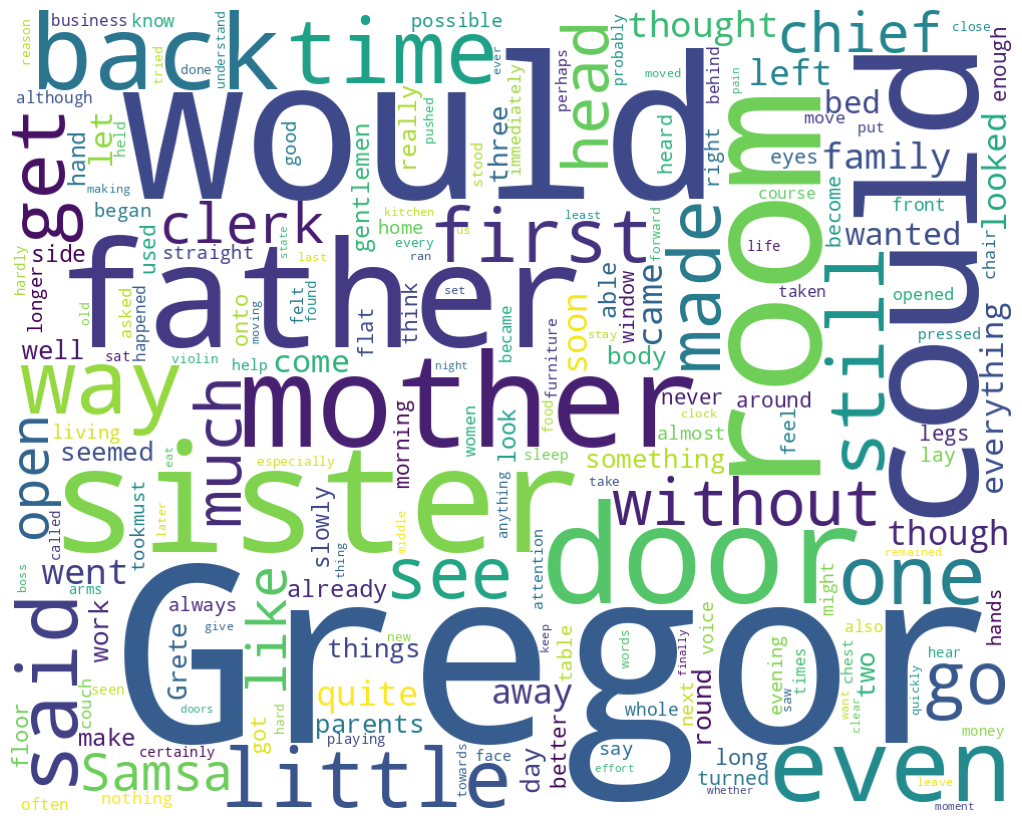

In [ ]:
# plot the WordCloud image
plt.figure(figsize = (10, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = -0.1)

plt.show()

In [ ]:
#Now working with all words lower case
all_words = [word.lower() for word in All_words]

In [ ]:
all_fd=nltk.FreqDist(all_words)

In [ ]:
single_words=all_fd.hapaxes()

In [ ]:
len(single_words)

1272

In [ ]:
import random

In [ ]:
random.choices(single_words,k=20)

['joined',
 'mistake',
 'ordeal',
 'prejudice',
 'spying',
 'ticking',
 'rock',
 'bulging',
 'saved',
 'expense',
 'victim',
 'retreating',
 'shorthand',
 'importune',
 'obsessed',
 'related',
 'anticipation',
 'bottle',
 'salt',
 'perversity']

In [ ]:
Top_words = [word for (word, freq) in All_fd.most_common(10)]
print(Top_words)

['Gregor', 'would', 'room', 'could', 'sister', 'father', 'door', 'mother', 'back', 'even']


In [ ]:
from nltk.draw.dispersion import dispersion_plot

<Figure size 1200x900 with 0 Axes>

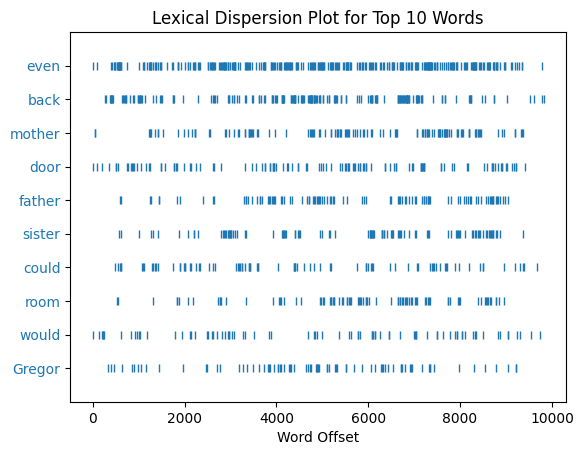

In [ ]:
plt.figure(figsize=(12, 9))
dispersion_plot(All_words, Top_words, ignore_case=True, title='Lexical Dispersion Plot for Top 10 Words')
plt.show()

In [ ]:
V = set(all_words)
long_words = [w for w in V if len(w) > 12]

In [ ]:
long_words

['unfortunately',
 'exceptionally',
 'consideration',
 'possibilities',
 'unsatisfactory',
 'uncontrollable',
 'recommendation',
 'simultaneously',
 'unpleasantness',
 'transformation',
 'unselfconsciously',
 'representative',
 'comprehension',
 'communication',
 'charlottenstrasse',
 'responsibility',
 'conversations',
 'congratulated',
 'circumstances',
 'incomprehensible',
 'uncomfortable',
 'unsuccessfully',
 'determination',
 'concentration',
 'deterioration',
 'consciousness',
 'establishment',
 'understanding',
 'disappointment']

In [ ]:
big_words=sorted(w for w in set(long_words) if len(w) > 10 and all_fd[w] > 7)
len(big_words)

0

In [ ]:
print(big_words)

[]


<Figure size 1200x900 with 0 Axes>

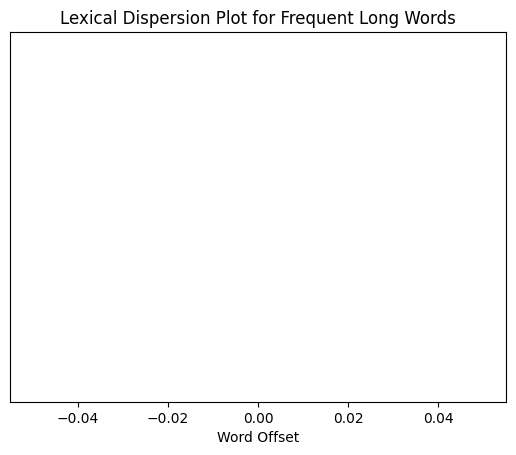

In [ ]:
plt.figure(figsize=(12, 9))
dispersion_plot(all_words, big_words, ignore_case=True, title='Lexical Dispersion Plot for Frequent Long Words')
plt.show()

# Bigrams and Trigrams

In [ ]:
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures


finder = BigramCollocationFinder.from_words(clean_tokens)



In [ ]:
frequent_bigrams = finder.nbest(BigramAssocMeasures.raw_freq, 100)
print(frequent_bigrams)

[('Gregor', 's'), ('of', 'the'), ('in', 'the'), ('he', 'had'), ('the', 'door'), ('his', 'sister'), ('he', 'was'), ('to', 'the'), ('it', 'was'), ('his', 'father'), ('on', 'the'), ('had', 'been'), ('that', 'he'), ('he', 'could'), ('as', 'he'), ('of', 'his'), ('as', 'if'), ('at', 'the'), ('from', 'the'), ('in', 'his'), ('to', 'be'), ('chief', 'clerk'), ('the', 'room'), ('his', 'mother'), ('into', 'the'), ('and', 'the'), ('did', 'not'), ('the', 'chief'), ('he', 'would'), ('all', 'the'), ('out', 'of'), ('she', 'had'), ('his', 'head'), ('if', 'he'), ('to', 'get'), ('to', 'him'), ('was', 'not'), ('with', 'his'), ('his', 'room'), ('with', 'the'), ('would', 'have'), ('a', 'little'), ('and', 'he'), ('had', 'to'), ('so', 'that'), ('they', 'had'), ('to', 'do'), ('to', 'his'), ('have', 'to'), ('on', 'his'), ('s', 'father'), ('It', 'was'), ('able', 'to'), ('at', 'all'), ('of', 'it'), ('wanted', 'to'), ('when', 'he'), ('with', 'a'), ('Gregor', 'had'), ('could', 'not'), ('had', 'not'), ('the', 'other'

In [ ]:
finder.apply_freq_filter(5)  # This filters out bigrams that occur less than 5 times
statistical_bigrams = finder.nbest(BigramAssocMeasures.raw_freq, 5)  # Adjust as needed
# also try bigram_measures.pmi, bigram_measures.chi_sq,likelihood_ratio,student_t,likelihood_ratio
statistical_bigrams


[('Gregor', 's'), ('of', 'the'), ('in', 'the'), ('he', 'had'), ('the', 'door')]

In [ ]:
finder.apply_freq_filter(5)  # This filters out bigrams that occur less than 5 times
statistical_bigrams = finder.nbest(BigramAssocMeasures.pmi, 5)  # Adjust as needed
# also try bigram_measures.pmi, bigram_measures.chi_sq,likelihood_ratio,student_t,likelihood_ratio
statistical_bigrams

[('o', 'clock'),
 ('chief', 'clerk'),
 ('three', 'gentlemen'),
 ('some', 'kind'),
 ('don', 't')]

In [ ]:
finder.apply_freq_filter(5)  # This filters out bigrams that occur less than 5 times
statistical_bigrams = finder.nbest(BigramAssocMeasures.likelihood_ratio, 5)  # Adjust as needed
# also try bigram_measures.pmi, bigram_measures.chi_sq,likelihood_ratio,student_t,likelihood_ratio
statistical_bigrams

[('Gregor', 's'),
 ('chief', 'clerk'),
 ('his', 'sister'),
 ('the', 'door'),
 ('his', 'father')]

In [ ]:
"o'clock".isalpha()

False

In [ ]:
len(statistical_bigrams)

5

In [ ]:
import random
from nltk import bigrams
from nltk.probability import ConditionalFreqDist

def generate_model(cfdist, word, num=15):
    for i in range(num):
        print(word, end=' ')
        # Get the most frequent next words (up to 3)
        next_words = list(cfdist[word].keys())[:3]
        if next_words:
            # Randomly choose from the top 3 words
            word = random.choice(next_words)
        else:
            break

# Your existing list of words
# clean_tokens = ["your", "list", "of", "word", "tokens", "here", "..."]  # Replace with your token list

# Generate bigrams from your list of words
clean_bigrams = bigrams(clean_tokens)

# Create a Conditional Frequency Distribution (CFD) from these bigrams
cfd = ConditionalFreqDist(clean_bigrams)

# Example usage
generate_model(cfd, 'She')  # Replace 'your_seed_word' with your desired starting word


She did in a little too noticeable He felt before Oh which made them It 

In [ ]:
generate_model(cfd, 'He')

He felt much more like this takes much hungrier than usual He lay on his 

In [ ]:
from nltk.collocations import TrigramAssocMeasures, TrigramCollocationFinder



# Create a trigram measures object
trigram_measures = TrigramAssocMeasures()

# Create a Trigram finder
finder = TrigramCollocationFinder.from_words(clean_tokens)

# You can then find trigrams using different measures, e.g., by raw frequency
trigrams = finder.nbest(trigram_measures.pmi, 10)  # top 10 trigrams
# trigrams = finder.nbest(trigram_measures.pmi, 20)  # top 10 trigrams
# trigrams=finder.nbest(trigram_measures.likelihood_ratio,20)

# Print trigrams
for trigram in trigrams:
    print(trigram)


('bow', 'hang', 'limply')
('earth', 'mingled', 'inseparably')
('lamps', 'shone', 'palely')
('robust', 'bone', 'structure')
('sew', 'fancy', 'underwear')
('sleeve', 'whisper', 'endearments')
('caustic', 'medicine', 'splashed')
('electric', 'motors', 'An')
('frequent', 'anxious', 'glances')
('grey', 'earth', 'mingled')


In [ ]:
from nltk import trigrams


def generate_model(cfdist, word1, word2, num=15):
    print(word1, word2, end=' ')
    for i in range(num - 2):  # Adjust the range since two words are already printed
        next_words = list(cfdist[(word1, word2)].keys())[:3]
        if next_words:
            next_word = random.choice(next_words)
            print(next_word, end=' ')
            word1, word2 = word2, next_word
        else:
            break


# Your existing list of words
# clean_tokens = ["your", "list", "of", "word", "tokens", "here", "..."]

# Generate trigrams from your list of words
clean_trigrams = trigrams(clean_tokens)

# Create a Conditional Frequency Distribution (CFD) from these trigrams
cfd = ConditionalFreqDist(((w1, w2), w3) for w1, w2, w3 in clean_trigrams)

# Example usage, with two seed words
generate_model(cfd, 'The', 'only')  # Replace with your desired starting words


The only 

In [ ]:
#

# Lemmmatization, contractions

First let's normalize contractions. So we hope to replace things like "let's" with "let us" and "can't" with "cannot", etc.

In [ ]:
!pip install contractions
import contractions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.8/110.8 kB 12.0 MB/s eta 0:00:00


In [ ]:
help(contractions)

Help on package contractions:

NAME
    contractions

PACKAGE CONTENTS
    data (package)
    test___init__

FUNCTIONS
    add(key, value)
    
    fix(s, leftovers=True, slang=True)
    
    get_combinations(tokens, joiners)
    
    intersperse(lst, item)
    
    preview(text, flank)
        Return all contractions and their location before fix for manual check. Also provide a viewing window to quickly
        preview the contractions in the text.
        :param text: texture.
        :param flank: int number, control the size of the preview window. The window would be "flank-contraction-flank".
        :return: preview_items, a list includes all matched contractions and their locations.

DATA
    comb = "you'd've"
    contractions_dict = {"'cause": 'because', "'em": 'them', "'tis": 'it i...
    json_open = b'{\n     "\'aight": "alright",\n     "abt": "ab...a": "wa...
    k = 'you’d’ve'
    leftovers_dict = {"'all": '', "'am": '', "'cause": 'because', "'coz": ...
    month = 'decemb

In [ ]:
expanded_text = contractions.fix(raw)

In [ ]:
# expanded_text

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Initialize the WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

# Assuming 'expanded_text' is your text after expanding contractions
# expanded_text = "Your expanded text here"

# Tokenize the text
tokens = word_tokenize(expanded_text)

# Lemmatize each word
lemmatized_text = ' '.join([lemmatizer.lemmatize(token) for token in tokens])

lemmatized_text


'One morning , when Gregor Samsa woke from troubled dream , he found himself transformed in his bed into a horrible vermin . He lay on his armour-like back , and if he lifted his head a little he could see his brown belly , slightly domed and divided by arch into stiff section . The bedding wa hardly able to cover it and seemed ready to slide off any moment . His many leg , pitifully thin compared with the size of the rest of him , waved about helplessly a he looked . “ What is happened to me ? ” he thought . It wa not a dream . His room , a proper human room although a little too small , lay peacefully between it four familiar wall . A collection of textile sample lay spread out on the table—Samsa wa a travelling salesman—and above it there hung a picture that he had recently cut out of an illustrated magazine and housed in a nice , gilded frame . It showed a lady fitted out with a fur hat and fur boa who sat upright , raising a heavy fur muff that covered the whole of her lower arm t

In [ ]:
lemmatized_text[30:200]

'a woke from troubled dream , he found himself transformed in his bed into a horrible vermin . He lay on his armour-like back , and if he lifted his head a little he could'

In [ ]:
all_tokens=word_tokenize(lemmatized_text)#.lower())

In [ ]:
clean_tokens=[word for word in all_tokens if word.isalpha()]

In [ ]:
print(clean_tokens[0:100])

['One', 'morning', 'when', 'Gregor', 'Samsa', 'woke', 'from', 'troubled', 'dream', 'he', 'found', 'himself', 'transformed', 'in', 'his', 'bed', 'into', 'a', 'horrible', 'vermin', 'He', 'lay', 'on', 'his', 'back', 'and', 'if', 'he', 'lifted', 'his', 'head', 'a', 'little', 'he', 'could', 'see', 'his', 'brown', 'belly', 'slightly', 'domed', 'and', 'divided', 'by', 'arch', 'into', 'stiff', 'section', 'The', 'bedding', 'wa', 'hardly', 'able', 'to', 'cover', 'it', 'and', 'seemed', 'ready', 'to', 'slide', 'off', 'any', 'moment', 'His', 'many', 'leg', 'pitifully', 'thin', 'compared', 'with', 'the', 'size', 'of', 'the', 'rest', 'of', 'him', 'waved', 'about', 'helplessly', 'a', 'he', 'looked', 'What', 'is', 'happened', 'to', 'me', 'he', 'thought', 'It', 'wa', 'not', 'a', 'dream', 'His', 'room', 'a', 'proper']


In [ ]:
All_words = [word for word in clean_tokens if word.casefold() not in stop_words]

In [ ]:
print(All_words[0:100])

['One', 'morning', 'Gregor', 'Samsa', 'woke', 'troubled', 'dream', 'found', 'transformed', 'bed', 'horrible', 'vermin', 'lay', 'back', 'lifted', 'head', 'little', 'could', 'see', 'brown', 'belly', 'slightly', 'domed', 'divided', 'arch', 'stiff', 'section', 'bedding', 'wa', 'hardly', 'able', 'cover', 'seemed', 'ready', 'slide', 'moment', 'many', 'leg', 'pitifully', 'thin', 'compared', 'size', 'rest', 'waved', 'helplessly', 'looked', 'happened', 'thought', 'wa', 'dream', 'room', 'proper', 'human', 'room', 'although', 'little', 'small', 'lay', 'peacefully', 'four', 'familiar', 'wall', 'collection', 'textile', 'sample', 'lay', 'spread', 'wa', 'travelling', 'hung', 'picture', 'recently', 'cut', 'illustrated', 'magazine', 'housed', 'nice', 'gilded', 'frame', 'showed', 'lady', 'fitted', 'fur', 'hat', 'fur', 'boa', 'sat', 'upright', 'raising', 'heavy', 'fur', 'muff', 'covered', 'whole', 'lower', 'arm', 'towards', 'viewer', 'Gregor', 'turned']


In [ ]:
All_fd=nltk.FreqDist(All_words)

In [ ]:
All_fd

FreqDist({'wa': 410, 'Gregor': 298, 'would': 200, 'room': 132, 'could': 126, 'sister': 101, 'father': 99, 'door': 96, 'mother': 85, 'back': 83, ...})

In [ ]:
wordcloud = WordCloud(width = 1000, height = 800,
                      background_color ='white',
                      max_words=200,
                      prefer_horizontal=0.5,
                      random_state=4,
                      contour_color='steelblue').generate_from_frequencies(All_fd)

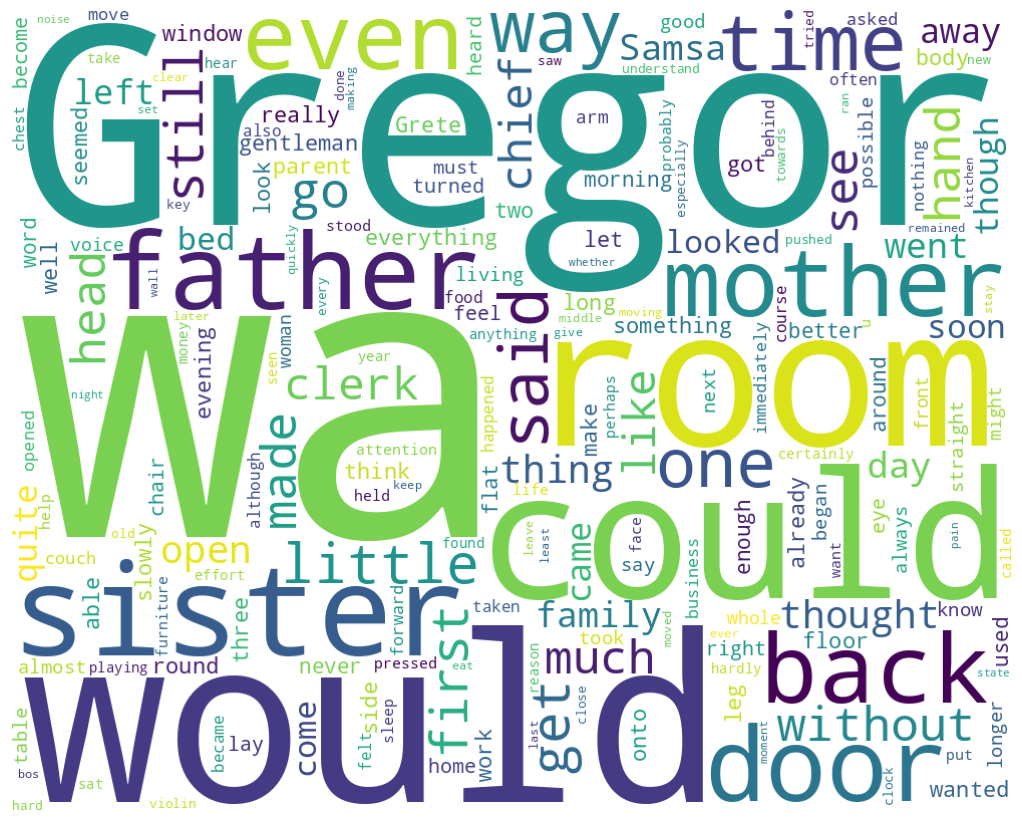

In [ ]:
# plot the WordCloud image
plt.figure(figsize = (10, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = -0.1)

plt.show()

In [ ]:
Top_words = [word for (word, freq) in All_fd.most_common(10)]
print(Top_words)

['wa', 'Gregor', 'would', 'room', 'could', 'sister', 'father', 'door', 'mother', 'back']


<Figure size 1200x900 with 0 Axes>

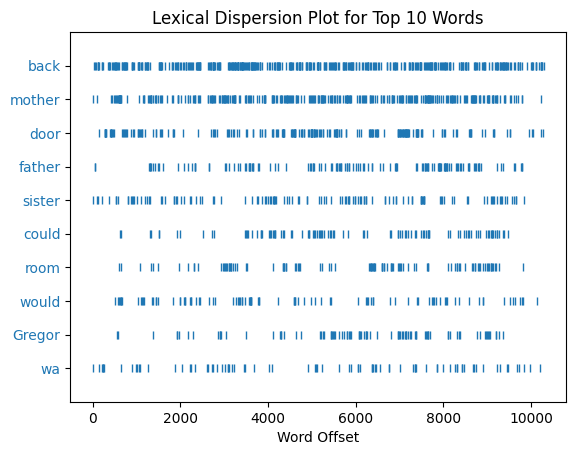

In [ ]:
plt.figure(figsize=(12, 9))
dispersion_plot(All_words, Top_words, ignore_case=True, title='Lexical Dispersion Plot for Top 10 Words')
plt.show()